In [74]:
import pandas as pd
from pathlib import Path
import numpy as np
import time
import os
import statsmodels
import seaborn as sns
import matplotlib.pyplot as plt
import glob
from scipy import stats
from scipy.stats import ttest_rel
import pingouin as pg
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf

In [75]:
def coefplot_gap(results, multiple_models=False, fig_name=None):
    '''
    Creates a coefficient plot with confidence intervals.
   
    Parameters:
    results : statsmodels results object or DataFrame
        If multiple_models=False: statsmodels results object
        If multiple_models=True: DataFrame with columns: index, model, Coef., [0.025, P>|z|
    multiple_models : bool, default False
        Whether to create a plot for multiple models or single model
   
    Returns:
        matplotlib plot
    '''
    # Create/process dataframe based on input type
    if not multiple_models:
        coef_df = pd.DataFrame(results.summary().tables[1]).reset_index()
    else:
        coef_df = results.copy()
   
    # Drop unwanted rows
    coef_df = coef_df.loc[coef_df["index"].isin(['Group Var', 'Intercept']) == False]
   
    # Convert numeric columns to float
    coef_df['Coef.'] = coef_df['Coef.'].astype(float)
    coef_df['[0.025'] = coef_df['[0.025'].astype(float)
    coef_df['P>|z|'] = coef_df['P>|z|'].astype(float)
   
    # Calculate errors
    coef_df['errors'] = coef_df['Coef.'] - coef_df['[0.025']
   
    # Create significance indicators - make them consistent between both cases
    if multiple_models:
        coef_df['Significance'] = coef_df['P>|z|'].apply(
            lambda x: 'Significant' if x < 0.05 else 'Not Significant'
        )
    else:
        # Changed to match the multiple models case
        coef_df['Significance'] = coef_df['P>|z|'].apply(
            lambda x: 'Significant' if x < 0.05 else 'Not Significant'
        )
   
    # Clean up Treatment variable names
    for var_name in coef_df['index'].unique():
        if "Treatment" in var_name:
            if ":" in var_name:
                var1 = var_name.split("[",1)[1].split("]")[0]
                var2 = var_name.split("[", 2)[-1]
                new_var_name = var1 + ":" + var2
            else:
                new_var_name = var_name.split("[", 1)[1].split("]")[0]
            coef_df['index'] = coef_df['index'].replace(var_name, new_var_name)
   
    # Create plot
    fig, ax = plt.subplots(figsize=(18, 10))
   
    # Define consistent marker styles
    marker_styles = {'Significant': 'X', 'Not Significant': 'o'}
   

    if multiple_models:
        # Get models and calculate positions
        models = coef_df['model'].unique()
        variables = coef_df['index'].unique()
        n_models = len(models)
        space_between = 2.5
        model_spacing = 1.0
       
        # Create position mapping
        positions = {}
        # Sort variables by their average coefficient value (lowest to highest)
        var_means = coef_df.groupby('index')['Coef.'].mean().sort_values()
        sorted_vars = var_means.index
       
        for i, var in enumerate(sorted_vars):
            base_pos = i * (n_models + space_between)
            for j, model in enumerate(models):
                positions[(var, model)] = base_pos + (j * model_spacing)
       
        # Add plot positions
        coef_df['plot_position'] = coef_df.apply(
            lambda row: positions[(row['index'], row['model'])],
            axis=1
        )
       
        # Set up colors for multiple models
        model_palette = sns.color_palette("husl", n_colors=len(models))
        model_colors = dict(zip(models, model_palette))
       
        # Plot error bars
        for model in models:
            model_data = coef_df[coef_df['model'] == model]
            plt.errorbar(x=model_data['Coef.'],
                        y=model_data['plot_position'],
                        xerr=model_data['errors'],
                        color=model_colors[model],
                        capsize=3,
                        fmt='none',
                        alpha=0.7,
                        zorder=1)
       
        # Plot points
        g = sns.scatterplot(data=coef_df,
                           x='Coef.',
                           y='plot_position',
                           hue='model',
                           style='Significance',
                           markers=marker_styles,
                           palette=model_colors,
                           s=200,
                           zorder=3,
                           ax=ax)
       
        # Set y-ticks
        tick_positions = []
        for i, var in enumerate(sorted_vars):
            base_pos = i * (n_models + space_between)
            middle_pos = base_pos + ((n_models - 1) * model_spacing) / 2
            tick_positions.append(middle_pos)
       
        ax.set_yticks(tick_positions)
        ax.set_yticklabels(sorted_vars)
       
        # Create legends
        g.legend_.remove()
       
        # Model legend
        model_legend = ax.legend(
            title='Models',
            handles=[plt.Line2D([], [], marker='o', color=color, linestyle='None',
                               markersize=10, label=model)
                    for model, color in model_colors.items()],
            bbox_to_anchor=(1.02, 1),
            loc='upper left'
        )
       
        # Significance legend
        significance_handles = [
            plt.Line2D([], [], marker='X', color='gray', linestyle='None',
                      markersize=10, label='Significant'),
            plt.Line2D([], [], marker='o', color='gray', linestyle='None',
                      markersize=10, label='Not Significant')
        ]
       
        ax.add_artist(model_legend)
        ax.legend(handles=significance_handles,
                 title='Significance',
                 bbox_to_anchor=(1.02, 0.6),
                 loc='upper left')
       
    else:
        # Sort the dataframe by coefficient values (lowest to highest)
        coef_df = coef_df.sort_values(by='Coef.', ascending=False)
       
        # Single model plot
        palette = sns.color_palette("Set1")
        color_map = {'Significant': palette[0], 'Not Significant': palette[1]}
       
        # Error bars
        for idx, row in coef_df.iterrows():
            error_color = color_map[row['Significance']]
            plt.errorbar(x=row['Coef.'],
                        y=row['index'],
                        xerr=row['errors'],
                        color=error_color,
                        capsize=3,
                        fmt='none',
                        zorder=1)
       
        # Scatter plot with consistent markers
        g = sns.scatterplot(y='index',
                           x='Coef.',
                           style='Significance',
                           hue='Significance',
                           markers=marker_styles,
                           palette=color_map,
                           s=200,
                           data=coef_df,
                           zorder=3,
                           ax=ax)
   
    # Common plot elements
    ax.axvline(x=0, linestyle='--', color='red', linewidth=1)
   
    # Set title & labels
    title = 'Coefficients Across Models w/ 95% Confidence Intervals' if multiple_models else 'Coefficients of Features w/ 95% Confidence Intervals'
    plt.title(title, fontsize=30)
    ax.set_ylabel('Variables' if multiple_models else 'Coefficients', fontsize=22)
    ax.set_xlabel('Coefficient Value' if multiple_models else '', fontsize=22)
   
    # Set x-axis limits
    ax.set_xlim(coef_df['Coef.'].min() - max(coef_df['errors']),
                coef_df['Coef.'].max() + max(coef_df['errors']))
   
    plt.tight_layout()

    plt.show()
    return plt.show()

In [76]:
file_path = '/Users/audrey-annebeaudry/Desktop/VS_results.csv'

In [77]:
vs_eeg = pd.read_csv(file_path)
vs_eeg

,subject,diagnosis,condition_group,n_trials,roi_channels,N1_channel,N1_amplitude,N1_latency,P3_channel,P3_amplitude,P3_latency,alpha_power,gamma_power
0,0171M1,control,single_search,8,"E59,E92,E53,E87",E87,-6.087771e-07,0.140,E59,0.000003,0.384,4.108853e-14,4.630650e-14
1,0171M1,control,conjunction_search,21,"E59,E92,E53,E87",E87,-7.847545e-07,0.130,E59,0.000002,0.450,5.509481e-14,4.197132e-14
2,0131P,asd,single_search,8,"E59,E92,E53,E87",E92,-5.028659e-06,0.108,E92,0.000007,0.401,2.060469e-12,7.351868e-14
3,0131P,asd,conjunction_search,21,"E59,E92,E53,E87",E92,-4.171453e-06,0.080,E59,0.000024,0.319,2.349072e-12,6.683588e-14
4,0181F1,control,single_search,8,"E59,E92,E53,E87",E92,-2.457708e-06,0.115,E92,0.000004,0.430,2.744544e-13,4.436825e-14
...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,0179P,asd,conjunction_search,21,"E59,E92,E53,E87",E87,-2.589790e-06,0.094,E92,0.000010,0.307,5.580485e-13,5.279615e-14
188,0162P,asd,single_search,7,"E59,E92,E53,E87",E87,-4.216424e-06,0.129,E92,0.000010,0.302,1.275722e-12,4.851086e-14
189,0162P,asd,conjunction_search,21,"E59,E92,E53,E87",E59,-5.096566e-06,0.088,E92,0.000009,0.393,1.470207e-12,5.909632e-14
190,1052S1,control,single_search,4,"E59,E92,E53,E87",E92,-7.395075e-06,0.115,E59,0.000016,0.439,2.685232e-12,1.678350e-13


In [78]:
def remove_outliers_iqr(df, columns):
    original_len = len(df)
    df_clean = df.copy()
    
    print("=== Outlier Removal Summary ===")
    
    for col in columns:
        q1 = df_clean[col].quantile(0.25)
        q3 = df_clean[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        before = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
        after = len(df_clean)
        removed = before - after
        print(f"{col}: removed {removed} rows")

    total_removed = original_len - len(df_clean)
    print(f"\nTotal rows removed: {total_removed}")
    print(f" Remaining rows: {len(df_clean)} of original {original_len}")
    
    return df_clean

# Define columns for each section
section_1_cols = ['alpha_power', 'gamma_power']
section_2_cols = ['P3_amplitude', 'N1_amplitude']
section_3_cols = ['P3_latency', 'N1_latency']

# Run outlier removal
vs_eeg_cleaned = remove_outliers_iqr(vs_eeg, section_1_cols + section_2_cols + section_3_cols)
vs_eeg = vs_eeg_cleaned

=== Outlier Removal Summary ===
alpha_power: removed 14 rows
gamma_power: removed 12 rows
P3_amplitude: removed 10 rows
N1_amplitude: removed 5 rows
P3_latency: removed 0 rows
N1_latency: removed 0 rows

Total rows removed: 41
 Remaining rows: 151 of original 192


In [79]:
# look into Winzorisation (keep participant but put them at the last value of outlier): do it at different precentage (5 or 10%)

## Analysis to look at detail comparison

In [80]:
vs_eeg.columns
vs_eeg['condition_group'].unique()
vs_eeg[['alpha_power', 'gamma_power']].describe()

,alpha_power,gamma_power
count,1.510000e+02,1.510000e+02
mean,6.669708e-13,4.963913e-14
std,6.618847e-13,2.338966e-14
min,4.108853e-14,9.162791e-15
25%,2.127331e-13,3.254929e-14
50%,3.722044e-13,4.680589e-14
75%,9.146011e-13,6.473935e-14
max,3.150740e-12,1.249012e-13


In [81]:
vs_eeg

,subject,diagnosis,condition_group,n_trials,roi_channels,N1_channel,N1_amplitude,N1_latency,P3_channel,P3_amplitude,P3_latency,alpha_power,gamma_power
0,0171M1,control,single_search,8,"E59,E92,E53,E87",E87,-6.087771e-07,0.140,E59,0.000003,0.384,4.108853e-14,4.630650e-14
1,0171M1,control,conjunction_search,21,"E59,E92,E53,E87",E87,-7.847545e-07,0.130,E59,0.000002,0.450,5.509481e-14,4.197132e-14
2,0131P,asd,single_search,8,"E59,E92,E53,E87",E92,-5.028659e-06,0.108,E92,0.000007,0.401,2.060469e-12,7.351868e-14
4,0181F1,control,single_search,8,"E59,E92,E53,E87",E92,-2.457708e-06,0.115,E92,0.000004,0.430,2.744544e-13,4.436825e-14
5,0181F1,control,conjunction_search,21,"E59,E92,E53,E87",E59,-4.203043e-06,0.140,E59,0.000004,0.428,4.464054e-13,4.396368e-14
...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,1147S2,control,conjunction_search,21,"E59,E92,E53,E87",E87,-2.820867e-06,0.117,E92,0.000004,0.420,3.816790e-13,3.259424e-14
186,0179P,asd,single_search,8,"E59,E92,E53,E87",E87,-3.777601e-06,0.103,E92,0.000007,0.327,7.673373e-13,5.758248e-14
187,0179P,asd,conjunction_search,21,"E59,E92,E53,E87",E87,-2.589790e-06,0.094,E92,0.000010,0.307,5.580485e-13,5.279615e-14
188,0162P,asd,single_search,7,"E59,E92,E53,E87",E87,-4.216424e-06,0.129,E92,0.000010,0.302,1.275722e-12,4.851086e-14


In [82]:
vs_eeg['alpha_power'] =  np.log(vs_eeg['alpha_power'])
vs_eeg['gamma_power'] =  np.log(vs_eeg['gamma_power'])
vs_eeg['N1_amplitude'] =  np.log(vs_eeg['N1_amplitude']) #log of a negative = NaN (should we make them positive value) = do the absolute value
vs_eeg['P3_amplitude'] =  np.log(vs_eeg['P3_amplitude']) 

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [83]:
vs_eeg

,subject,diagnosis,condition_group,n_trials,roi_channels,N1_channel,N1_amplitude,N1_latency,P3_channel,P3_amplitude,P3_latency,alpha_power,gamma_power
0,0171M1,control,single_search,8,"E59,E92,E53,E87",E87,NaN,0.140,E59,-12.781416,0.384,-30.823047,-30.703494
1,0171M1,control,conjunction_search,21,"E59,E92,E53,E87",E87,NaN,0.130,E59,-13.257138,0.450,-30.529721,-30.801790
2,0131P,asd,single_search,8,"E59,E92,E53,E87",E92,NaN,0.108,E92,-11.839773,0.401,-26.908088,-30.241237
4,0181F1,control,single_search,8,"E59,E92,E53,E87",E92,NaN,0.115,E92,-12.338126,0.430,-28.923991,-30.746252
5,0181F1,control,conjunction_search,21,"E59,E92,E53,E87",E59,NaN,0.140,E59,-12.489645,0.428,-28.437549,-30.755413
...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,1147S2,control,conjunction_search,21,"E59,E92,E53,E87",E87,NaN,0.117,E92,-12.489410,0.420,-28.594197,-31.054641
186,0179P,asd,single_search,8,"E59,E92,E53,E87",E87,NaN,0.103,E92,-11.814103,0.327,-27.895850,-30.485558
187,0179P,asd,conjunction_search,21,"E59,E92,E53,E87",E87,NaN,0.094,E92,-11.513266,0.307,-28.214330,-30.572338
188,0162P,asd,single_search,7,"E59,E92,E53,E87",E87,NaN,0.129,E92,-11.465708,0.302,-27.387509,-30.656989


In [48]:
vs_eeg_clean = vs_eeg.dropna(subset=['alpha_power', 'gamma_power', 'condition_group'])

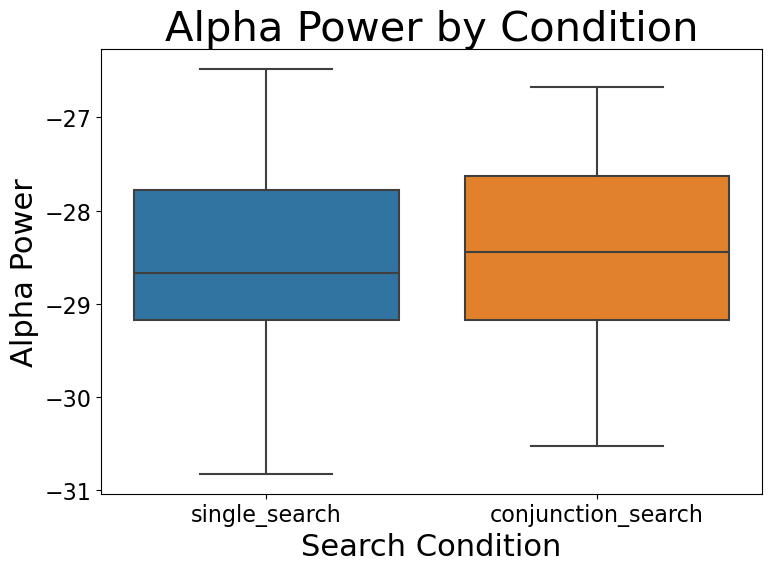

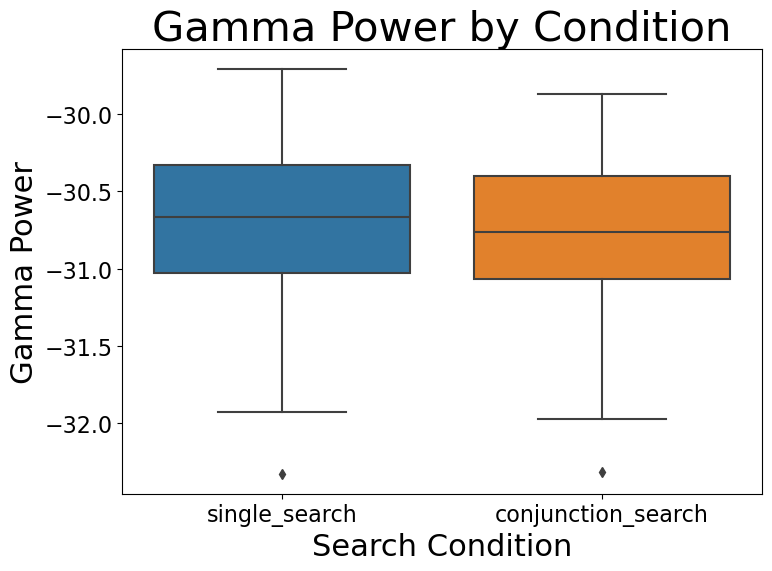

In [49]:
# ALPHA
plt.figure(figsize=(8, 6))
sns.boxplot(data=vs_eeg_clean, x='condition_group', y='alpha_power')
plt.title('Alpha Power by Condition')
plt.ylabel('Alpha Power')
plt.xlabel('Search Condition')
plt.tight_layout()
plt.show()

# GAMMA
plt.figure(figsize=(8, 6))
sns.boxplot(data=vs_eeg_clean, x='condition_group', y='gamma_power')
plt.title('Gamma Power by Condition')
plt.ylabel('Gamma Power')
plt.xlabel('Search Condition')
plt.tight_layout()
plt.show()

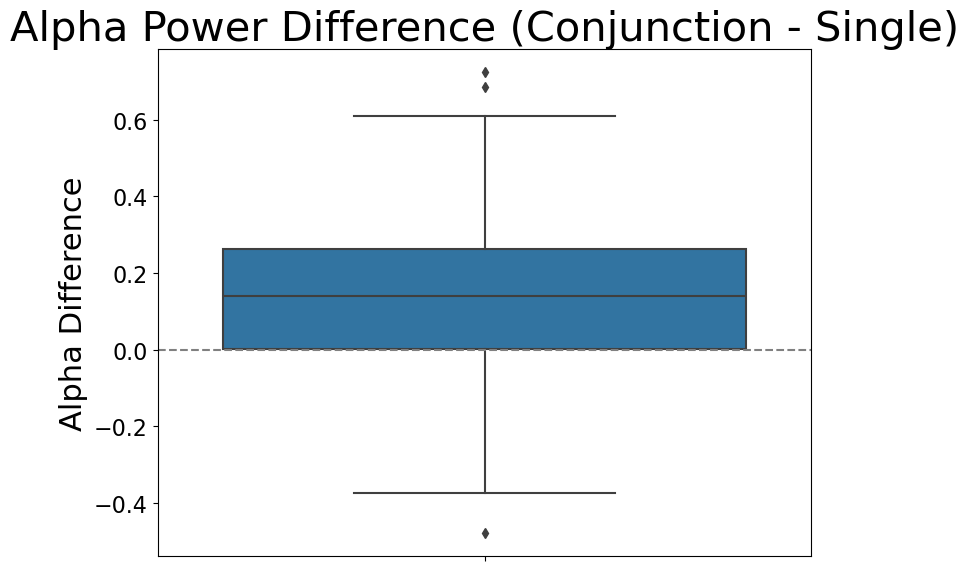

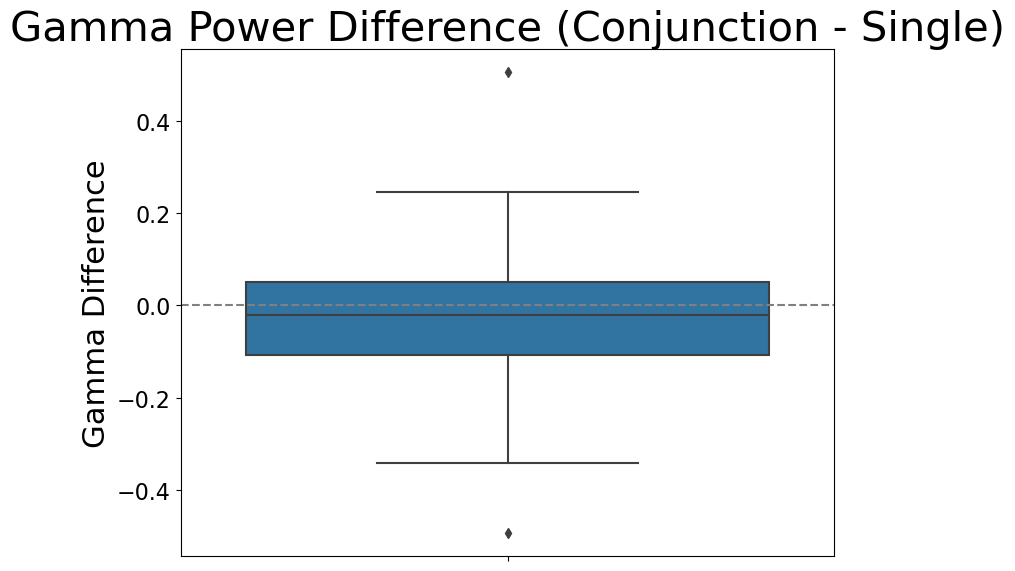

In [50]:
# Pivot the data to get one row per subject per condition
pivot_df = vs_eeg_clean.pivot_table(index='subject', 
                                 columns='condition_group', 
                                 values=['alpha_power', 'gamma_power'])

# Flatten MultiIndex columns
pivot_df.columns = ['_'.join(col).strip() for col in pivot_df.columns.values]
pivot_df = pivot_df.dropna()  # remove subjects missing either condition

# Add subtraction columns (conjunction - single)
pivot_df['alpha_diff'] = pivot_df['alpha_power_conjunction_search'] - pivot_df['alpha_power_single_search']
pivot_df['gamma_diff'] = pivot_df['gamma_power_conjunction_search'] - pivot_df['gamma_power_single_search']

# Boxplots of differences
#ALPHA
plt.figure(figsize=(8, 6))
sns.boxplot(y=pivot_df['alpha_diff'])
plt.title('Alpha Power Difference (Conjunction - Single)')
plt.ylabel('Alpha Difference')
plt.axhline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

#GAMMA
plt.figure(figsize=(8, 6))
sns.boxplot(y=pivot_df['gamma_diff'])
plt.title('Gamma Power Difference (Conjunction - Single)')
plt.ylabel('Gamma Difference')
plt.axhline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

In [51]:
# Alpha
t_alpha = ttest_rel(pivot_df['alpha_power_conjunction_search'], pivot_df['alpha_power_single_search'])
print('Alpha Paired t-test:', t_alpha)

# Gamma
t_gamma = ttest_rel(pivot_df['gamma_power_conjunction_search'], pivot_df['gamma_power_single_search'])
print('Gamma Paired t-test:', t_gamma)

Alpha Paired t-test: TtestResult(statistic=4.722479023720305, pvalue=1.1844540524612784e-05, df=69)
Gamma Paired t-test: TtestResult(statistic=-1.2896862902011623, pvalue=0.20146571866826674, df=69)


#### NOTES: 
#### Alpha Power : t(95) = 3.61, p = 0.00056 = statistically significant
#### There is a difference in conjunction VS single search conditions across participants. Since alpha is typically reduced (suppressed) when attention is high, this suggests participants engaged more attention in one condition (single). = "motivation" hypothesis not confirmed.
#### Gamma Power: t(95) = 0.27, p = 0.79 = Not significant
#### Gamma power did not differ between single and conjunction conditions across participants. 

In [52]:
vs_eeg.groupby('diagnosis')['alpha_power'].mean()

diagnosis
asd       -28.043622
control   -28.643201
Name: alpha_power, dtype: float64

#### NOTES:
#### Since higher alpha power = less attentional engagement, ASD participants show less alpha suppression (i.e., potentially less attentional engagement) than controls — across all trials.
#### Differences in attentional strategies, cognitive load processing differences, Or possibly increased baseline alpha

In [14]:
# Remove NaNs from alpha_power column
#vs_eeg_clean = vs_eeg.dropna(subset=['alpha_power'])

# Run two-way ANOVA
#model = ols('alpha_power ~ C(condition_group) * C(diagnosis)', data=vs_eeg_clean).fit()
#anova_table = sm.stats.anova_lm(model, typ=2)

#anova_table

#### NOTES:
#### ASD participants have higher alpha power across both task types.
#### conjunction vs. single does not affect alpha power.
#### There's no interaction

In [15]:
# Remove NaNs from alpha_power column
#vs_eeg_clean = vs_eeg.dropna(subset=['gamma_power'])

# Run two-way ANOVA
#model = ols('gamma_power ~ C(condition_group) * C(diagnosis)', data=vs_eeg_clean).fit()
#anova_table = sm.stats.anova_lm(model, typ=2)

#anova_table

## Analysis to look at ASD vs CONTROL

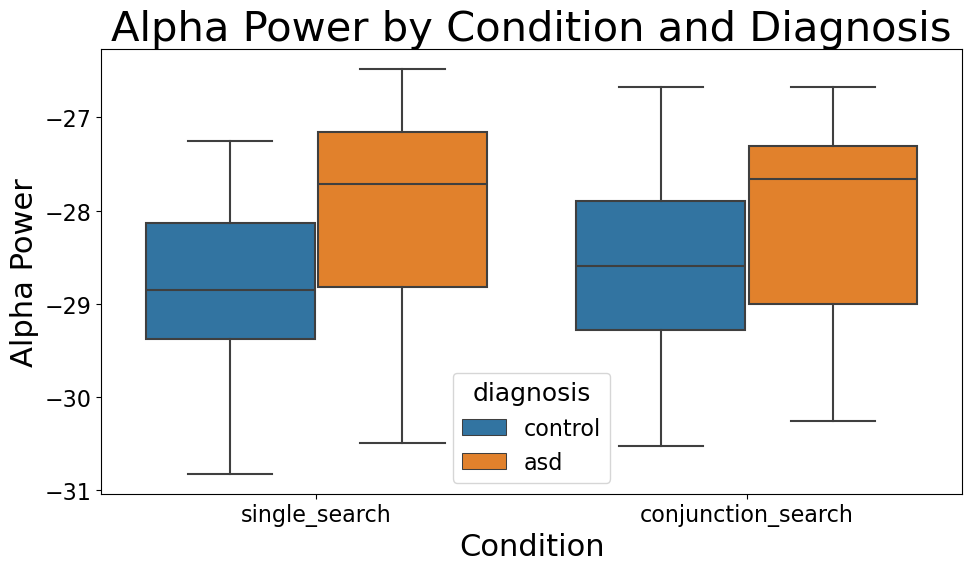

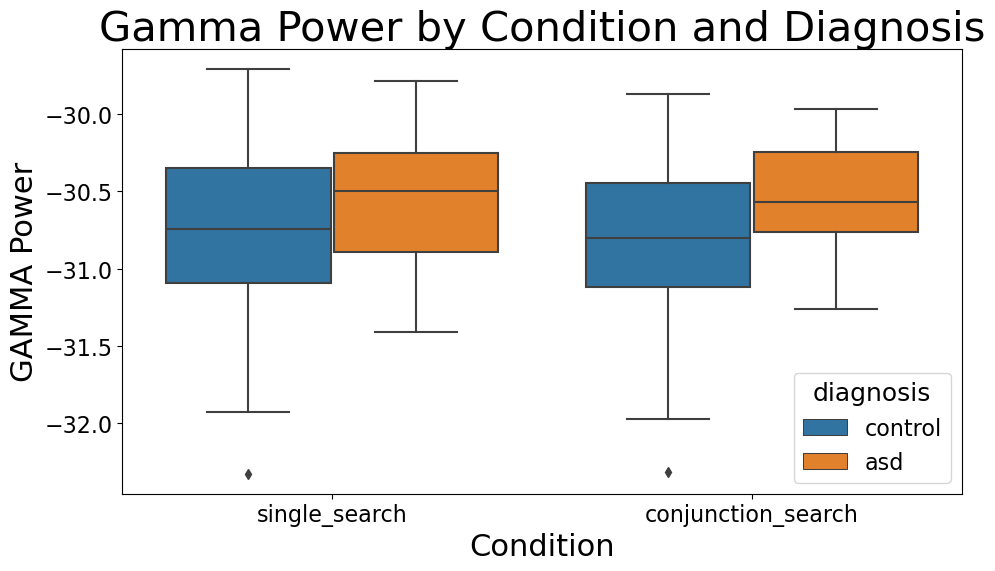

In [53]:
#Alpha
plt.figure(figsize=(10, 6))
sns.boxplot(data=vs_eeg, x='condition_group', y='alpha_power', hue='diagnosis')
plt.title('Alpha Power by Condition and Diagnosis')
plt.ylabel('Alpha Power')
plt.xlabel('Condition')
plt.tight_layout()
plt.show()

#Gamma
plt.figure(figsize=(10, 6))
sns.boxplot(data=vs_eeg, x='condition_group', y='gamma_power', hue='diagnosis')
plt.title('Gamma Power by Condition and Diagnosis')
plt.ylabel('GAMMA Power')
plt.xlabel('Condition')
plt.tight_layout()
plt.show()


/var/folders/l2/gldr348j5ngb9kyqkcy1nswh0000gn/T/ipykernel_46254/3805127779.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=vs_eeg_clean, x='diagnosis', y='alpha_power', ci='sd')


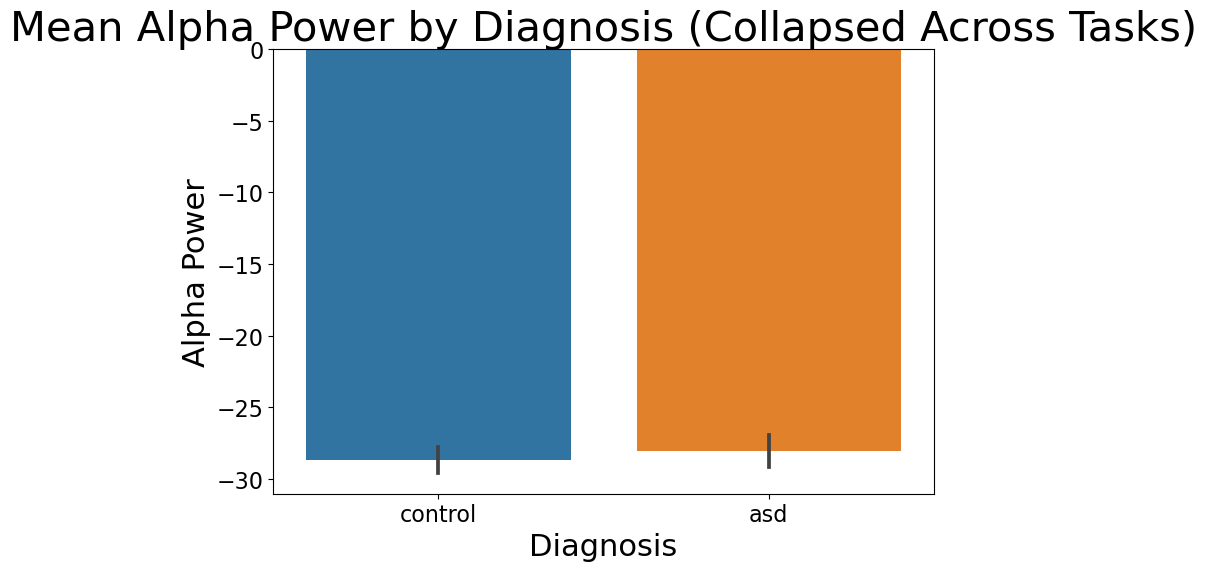

/var/folders/l2/gldr348j5ngb9kyqkcy1nswh0000gn/T/ipykernel_46254/3805127779.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=vs_eeg_clean, x='diagnosis', y='gamma_power', ci='sd')


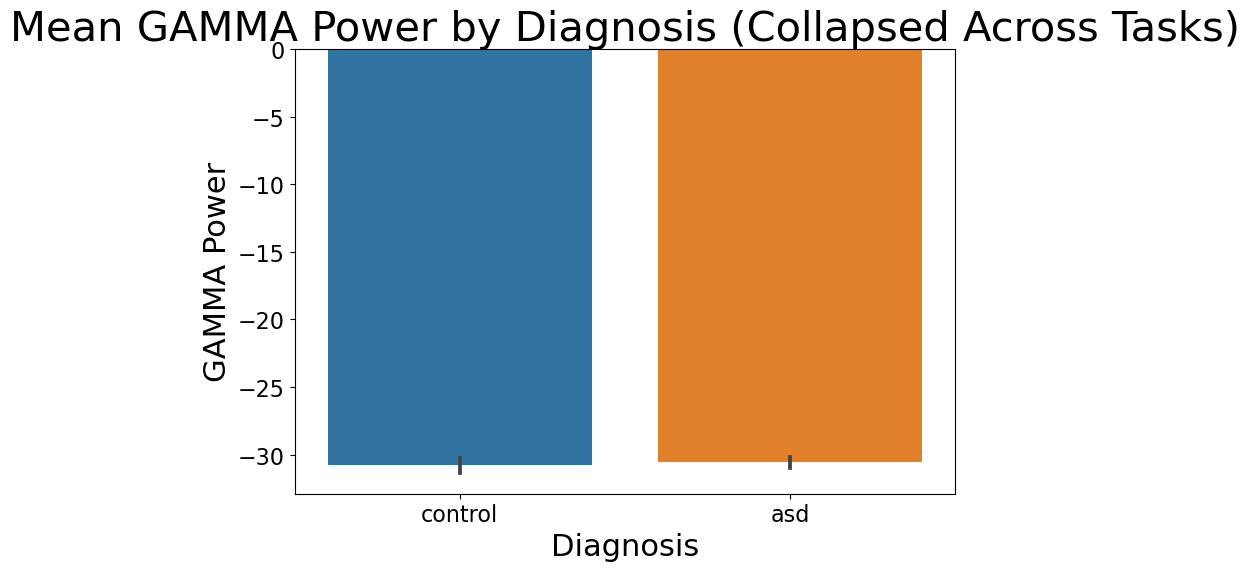

In [54]:
#Alpha
plt.figure(figsize=(8, 6))
sns.barplot(data=vs_eeg_clean, x='diagnosis', y='alpha_power', ci='sd')
plt.title('Mean Alpha Power by Diagnosis (Collapsed Across Tasks)')
plt.ylabel('Alpha Power')
plt.xlabel('Diagnosis')
plt.tight_layout()
plt.show()
#Gamma 
plt.figure(figsize=(8, 6))
sns.barplot(data=vs_eeg_clean, x='diagnosis', y='gamma_power', ci='sd')
plt.title('Mean GAMMA Power by Diagnosis (Collapsed Across Tasks)')
plt.ylabel('GAMMA Power')
plt.xlabel('Diagnosis')
plt.tight_layout()
plt.show()

In [55]:
pg.normality(data=vs_eeg, dv='alpha_power', group='diagnosis')

,W,pval,normal
diagnosis,,,
control,0.987275,0.354806,True
asd,0.921659,0.014086,False


In [56]:
# Do log 10 for transformation (make sure) or ln 

In [57]:
pg.sphericity(data=vs_eeg, dv='alpha_power', subject='subject', within='condition_group', method='mauchly')

(True, nan, nan, 1, 1.0)

In [58]:
pg.homoscedasticity(data=vs_eeg, dv='N1_amplitude', group='diagnosis', method='levene')

,W,pval,equal_var
levene,NaN,NaN,False


In [59]:
alpha_anova = pg.mixed_anova(
    dv='alpha_power',
    within='condition_group',
    between='diagnosis',
    subject='subject',
    data=vs_eeg
).round(4)
alpha_anova

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,diagnosis,4.3804,1,68,4.3804,2.5993,0.1115,0.0368,NaN
1,condition_group,0.6762,1,68,0.6762,23.5167,0.0000,0.2570,1.0
2,Interaction,0.1368,1,68,0.1368,4.7588,0.0326,0.0654,NaN


In [60]:
post_hocs = pg.pairwise_tests(dv='alpha_power', within='condition_group',
                               subject='subject', between = 'diagnosis', padjust='fdr_bh', data=vs_eeg).round(5)
post_hocs

,Contrast,condition_group,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,condition_group,-,conjunction_search,single_search,True,True,4.72248,69.00000,two-sided,0.00001,NaN,nan,1499.442,0.14759
1,diagnosis,-,asd,control,False,True,1.39933,18.91109,two-sided,0.17790,NaN,nan,0.638,0.46442
2,condition_group * diagnosis,conjunction_search,asd,control,False,True,1.16742,19.87094,two-sided,0.25686,0.25686,fdr_bh,0.502,0.36920
3,condition_group * diagnosis,single_search,asd,control,False,True,1.60759,18.16616,two-sided,0.12517,0.25033,fdr_bh,0.821,0.55729


In [61]:
# Test the effects of group and condition on rt while accoutning for sex, age and site

# Create mixed effects model
model_formula = "alpha_power ~ C(diagnosis, Treatment(reference = 'control'))  * condition_group"

# Fit the model
model = smf.mixedlm(model_formula, vs_eeg, groups=vs_eeg["subject"],re_formula="~1").fit()

# Print the summary
model_summary = model.summary()
model_summary

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                               Mixed Linear Model Regression Results
====================================================================================================================================
Model:                                     MixedLM                          Dependent Variable:                          alpha_power
No. Observations:                          151                              Method:                                      REML       
No. Groups:                                81                               Scale:                                       0.0288     
Min. group size:                           1                                Log-Likelihood:                              -116.7564  
Max. group size:                           2                                Converged:                                   Yes        
Mean group size:                           1.9                                                                                      
------------------------------------------------------------------------------------------------------------------------------------
                                                                                      Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                            -28.507    0.127 -224.061 0.000 -28.756 -28.258
C(diagnosis, Treatment(reference='control'))[T.asd]                                    0.631    0.251    2.512 0.012   0.139   1.123
condition_group[T.single_search]                                                      -0.174    0.032   -5.373 0.000  -0.237  -0.110
C(diagnosis, Treatment(reference='control'))[T.asd]:condition_group[T.single_search]   0.159    0.070    2.276 0.023   0.022   0.295
Group Var                                                                              0.941    1.324                               
====================================================================================================================================

"""

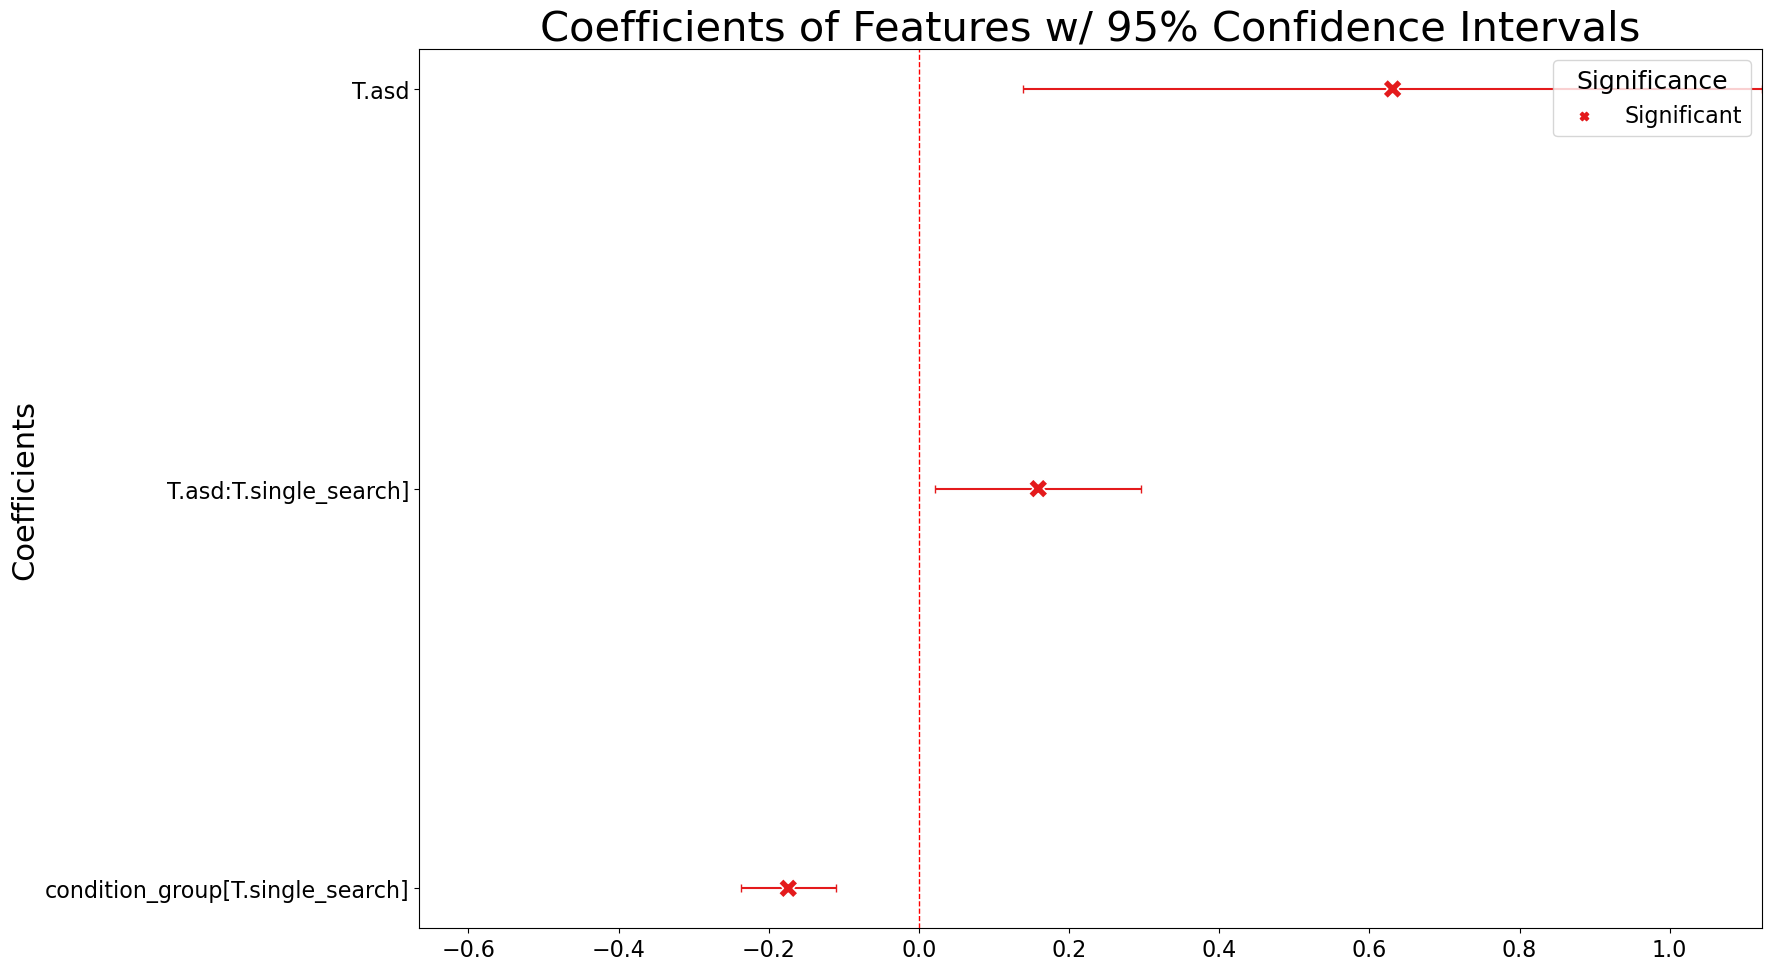

In [62]:
plt.rcParams.update({
    'font.size': 16,       # Base font size for ticks and text
    'axes.titlesize': 30,  # Title font
    'axes.labelsize': 22,  # Axis label font
    'xtick.labelsize': 16, # X-tick font
    'ytick.labelsize': 16, # Y-tick font
    'legend.fontsize': 16, # Legend font
    'legend.title_fontsize': 18  # Legend title font
})
coefplot_gap(model, multiple_models=False, fig_name='Simple Linear')
#nothing matters other than conditions (Faster 13 or 9)

In [63]:
#line in middle is the reference (control + conjunction)

In [64]:
pg.normality(data=vs_eeg, dv='gamma_power', group='diagnosis')

,W,pval,normal
diagnosis,,,
control,0.982006,0.125729,True
asd,0.966125,0.329321,True


In [65]:
pg.sphericity(data=vs_eeg, dv='alpha_power', subject='subject', within='condition_group', method='mauchly')

(True, nan, nan, 1, 1.0)

In [67]:
pg.homoscedasticity(data=vs_eeg, dv='alpha_power', group='diagnosis', method='levene')

,W,pval,equal_var
levene,2.424131,0.121601,True


In [68]:
gamma_anova = pg.mixed_anova(
    dv='gamma_power',
    within='condition_group',
    between='diagnosis',
    subject='subject',
    data=vs_eeg
).round(4)
gamma_anova

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,diagnosis,0.8081,1,68,0.8081,1.6066,0.2093,0.0231,NaN
1,condition_group,0.0165,1,68,0.0165,1.7928,0.1850,0.0257,1.0
2,Interaction,0.0588,1,68,0.0588,6.3737,0.0139,0.0857,NaN


In [69]:
post_hocs = pg.pairwise_tests(dv='gamma_power', within='condition_group',
                               subject='subject', between = 'diagnosis', padjust='fdr_bh', data=vs_eeg).round(5)
post_hocs

,Contrast,condition_group,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,condition_group,-,conjunction_search,single_search,True,True,-1.28969,69.00000,two-sided,0.20147,NaN,nan,0.29,-0.04250
1,diagnosis,-,asd,control,False,True,1.53370,30.74706,two-sided,0.13533,NaN,nan,0.748,0.36513
2,condition_group * diagnosis,conjunction_search,asd,control,False,True,1.96619,30.13795,two-sided,0.05855,0.11709,fdr_bh,1.37,0.47263
3,condition_group * diagnosis,single_search,asd,control,False,True,1.06132,29.63567,two-sided,0.29712,0.29712,fdr_bh,0.457,0.25724


In [70]:
# Test the effects of group and condition on rt while accoutning for sex, age and site

# Create mixed effects model
model_formula = "gamma_power ~ C(diagnosis, Treatment(reference = 'control'))  * condition_group"

# Fit the model
model = smf.mixedlm(model_formula, vs_eeg, groups=vs_eeg["subject"],re_formula="~1").fit()

# Print the summary
model_summary = model.summary()
model_summary

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                               Mixed Linear Model Regression Results
====================================================================================================================================
Model:                                     MixedLM                          Dependent Variable:                          gamma_power
No. Observations:                          151                              Method:                                      REML       
No. Groups:                                81                               Scale:                                       0.0092     
Min. group size:                           1                                Log-Likelihood:                              -23.2858   
Max. group size:                           2                                Converged:                                   Yes        
Mean group size:                           1.9                                                                                      
------------------------------------------------------------------------------------------------------------------------------------
                                                                                      Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                            -30.826    0.064 -483.427 0.000 -30.951 -30.701
C(diagnosis, Treatment(reference='control'))[T.asd]                                    0.345    0.126    2.737 0.006   0.098   0.592
condition_group[T.single_search]                                                       0.044    0.018    2.382 0.017   0.008   0.079
C(diagnosis, Treatment(reference='control'))[T.asd]:condition_group[T.single_search]  -0.100    0.039   -2.527 0.012  -0.177  -0.022
Group Var                                                                              0.234    0.583                               
====================================================================================================================================

"""

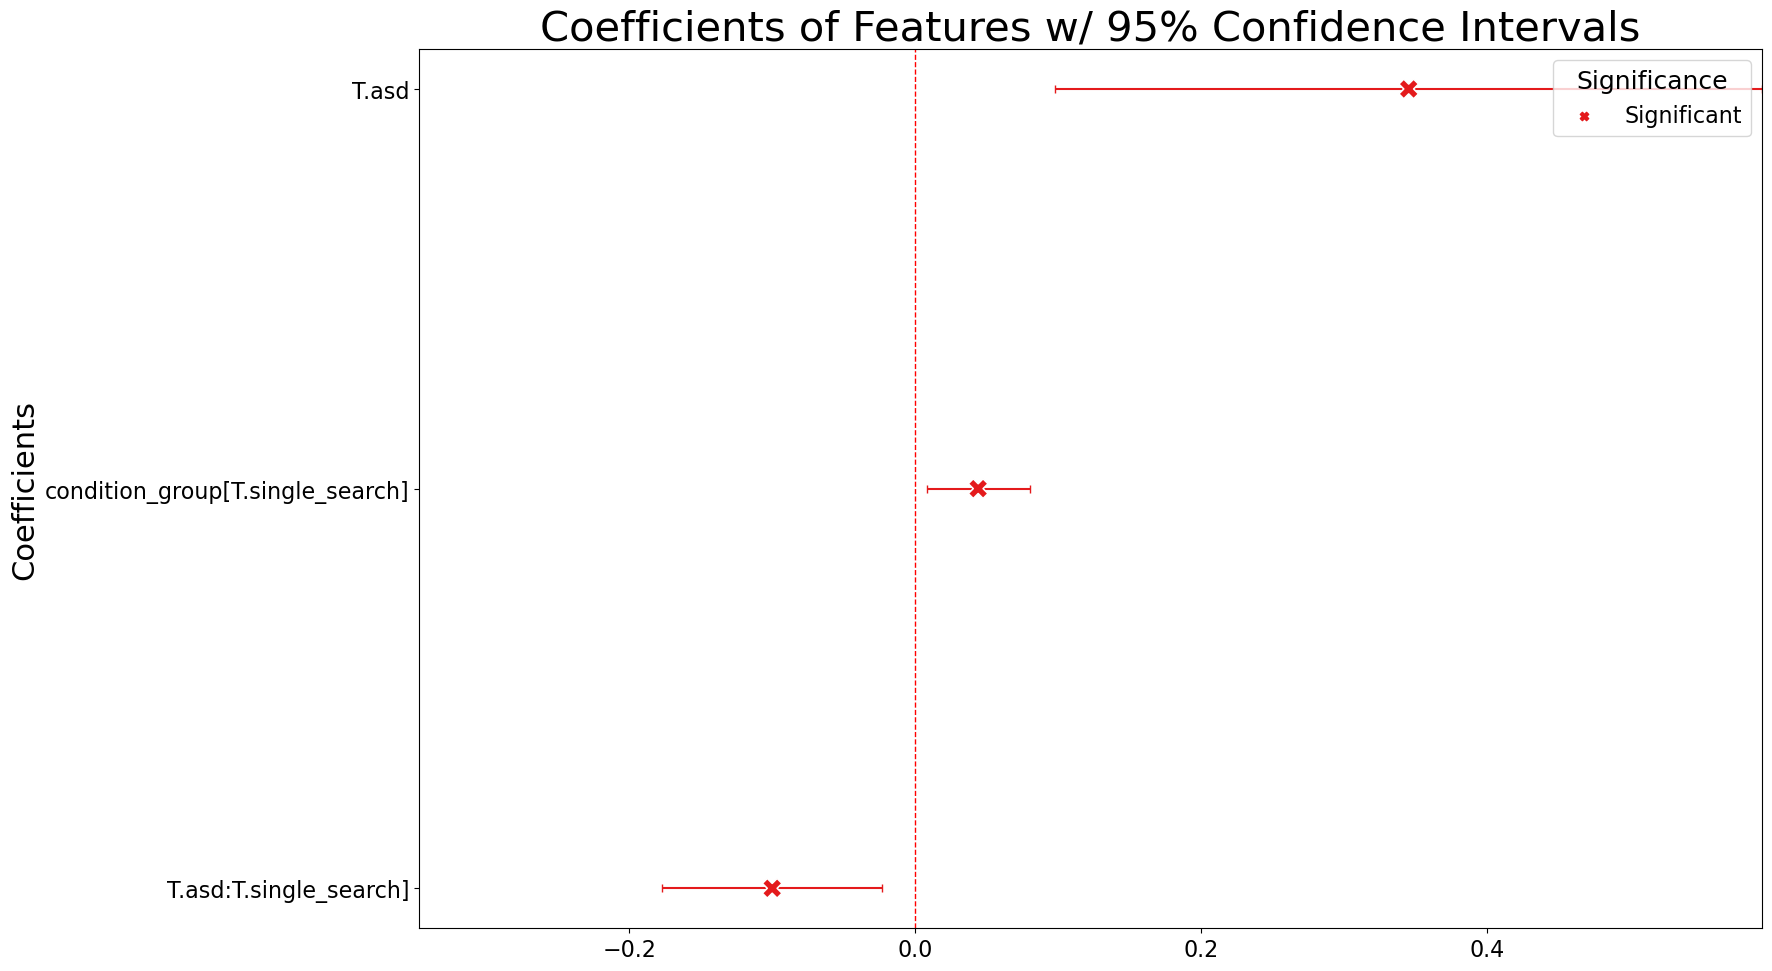

In [71]:
plt.rcParams.update({
    'font.size': 16,       # Base font size for ticks and text
    'axes.titlesize': 30,  # Title font
    'axes.labelsize': 22,  # Axis label font
    'xtick.labelsize': 16, # X-tick font
    'ytick.labelsize': 16, # Y-tick font
    'legend.fontsize': 16, # Legend font
    'legend.title_fontsize': 18  # Legend title font
})
coefplot_gap(model, multiple_models=False, fig_name='Simple Linear')
#nothing matters other than conditions (Faster 13 or 9)

In [34]:
#TO DO: ADD GAMMA VS ALPHA IN SAME GRAPH

## N1 and P3b analysis for amplitude

In [72]:
vs_eeg

,subject,diagnosis,condition_group,n_trials,roi_channels,N1_channel,N1_amplitude,N1_latency,P3_channel,P3_amplitude,P3_latency,alpha_power,gamma_power
0,0171M1,control,single_search,8,"E59,E92,E53,E87",E87,NaN,0.140,E59,-12.781416,0.384,-30.823047,-30.703494
1,0171M1,control,conjunction_search,21,"E59,E92,E53,E87",E87,NaN,0.130,E59,-13.257138,0.450,-30.529721,-30.801790
2,0131P,asd,single_search,8,"E59,E92,E53,E87",E92,NaN,0.108,E92,-11.839773,0.401,-26.908088,-30.241237
4,0181F1,control,single_search,8,"E59,E92,E53,E87",E92,NaN,0.115,E92,-12.338126,0.430,-28.923991,-30.746252
5,0181F1,control,conjunction_search,21,"E59,E92,E53,E87",E59,NaN,0.140,E59,-12.489645,0.428,-28.437549,-30.755413
...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,1147S2,control,conjunction_search,21,"E59,E92,E53,E87",E87,NaN,0.117,E92,-12.489410,0.420,-28.594197,-31.054641
186,0179P,asd,single_search,8,"E59,E92,E53,E87",E87,NaN,0.103,E92,-11.814103,0.327,-27.895850,-30.485558
187,0179P,asd,conjunction_search,21,"E59,E92,E53,E87",E87,NaN,0.094,E92,-11.513266,0.307,-28.214330,-30.572338
188,0162P,asd,single_search,7,"E59,E92,E53,E87",E87,NaN,0.129,E92,-11.465708,0.302,-27.387509,-30.656989


In [35]:
# N1
n1_pivot = vs_eeg.pivot_table(index=['subject', 'diagnosis'], 
                              columns='condition_group', 
                              values='N1_amplitude').dropna()
ttest_n1 = ttest_rel(n1_pivot['conjunction_search'], n1_pivot['single_search'])

# P3b
p3b_pivot = vs_eeg.pivot_table(index=['subject', 'diagnosis'], 
                               columns='condition_group', 
                               values='P3_amplitude').dropna()
ttest_p3b = ttest_rel(p3b_pivot['conjunction_search'], p3b_pivot['single_search'])

print("N1 Amplitude Paired t-test:", ttest_n1)
print("P3b Amplitude Paired t-test:", ttest_p3b)

KeyError: 'conjunction_search'

In [36]:
# N1
#n1_model = ols("N1_amplitude ~ C(condition_group) * C(diagnosis)", data=vs_eeg).fit()
#n1_anova = sm.stats.anova_lm(n1_model, typ=2)

# P3b
#p3b_model = ols("P3_amplitude ~ C(condition_group) * C(diagnosis)", data=vs_eeg).fit()
#p3b_anova = sm.stats.anova_lm(p3b_model, typ=2)

#print('N1 ANOVA:, P3b ANOVA:')
#n1_anova, p3b_anova


In [37]:
pg.normality(data=vs_eeg, dv='N1_amplitude', group='diagnosis')

/opt/anaconda3/lib/python3.11/site-packages/pingouin/distribution.py:242: UserWarning: Group control has less than 4 valid samples. Returning NaN.
  warnings.warn(f"Group {idx} has less than 4 valid samples. Returning NaN.")
/opt/anaconda3/lib/python3.11/site-packages/pingouin/distribution.py:242: UserWarning: Group asd has less than 4 valid samples. Returning NaN.
  warnings.warn(f"Group {idx} has less than 4 valid samples. Returning NaN.")


,W,pval,normal
diagnosis,,,
control,NaN,NaN,False
asd,NaN,NaN,False


In [38]:
pg.sphericity(data=vs_eeg, dv='N1_amplitude', subject='subject', within='condition_group', method='mauchly')

(True, nan, nan, 1, 1.0)

In [39]:
pg.homoscedasticity(data=vs_eeg, dv='N1_amplitude', group='diagnosis', method='levene')

,W,pval,equal_var
levene,NaN,NaN,False


In [73]:
n1_anova = pg.mixed_anova(
    dv='N1_amplitude',
    within='condition_group',
    between='diagnosis',
    subject='subject',
    data=vs_eeg
).round(4)
n1_anova

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,diagnosis,0.0,1,68,0.0,1.2217,0.2729,0.0176,NaN
1,condition_group,0.0,1,68,0.0,14.3023,0.0003,0.1738,1.0
2,Interaction,0.0,1,68,0.0,2.2527,0.1380,0.0321,NaN


In [100]:
post_hocs = pg.pairwise_tests(dv='N1_amplitude', within='condition_group',
                               subject='subject', between = 'diagnosis', padjust='fdr_bh', data=vs_eeg).round(5)
post_hocs

,Contrast,condition_group,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,condition_group,-,conjunction_search,single_search,True,True,3.74797,69.00000,two-sided,0.00037,NaN,nan,63.09,0.39451
1,diagnosis,-,asd,control,False,True,-0.98921,19.50283,two-sided,0.33468,NaN,nan,0.43,-0.31839
2,condition_group * diagnosis,conjunction_search,asd,control,False,True,-1.54219,19.64352,two-sided,0.13898,0.27797,fdr_bh,0.756,-0.49299
3,condition_group * diagnosis,single_search,asd,control,False,True,-0.27813,18.86149,two-sided,0.78394,0.78394,fdr_bh,0.299,-0.09256


In [175]:
# Test the effects of group and condition on rt while accoutning for sex, age and site

# Create mixed effects model
model_formula = "N1_amplitude ~ C(condition_group) * C(diagnosis)"

# Fit the model
model = smf.mixedlm(model_formula, vs_eeg, groups=vs_eeg["subject"],re_formula="~1").fit()

# Print the summary
model_summary = model.summary()
model_summary

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
                                Mixed Linear Model Regression Results
======================================================================================================
Model:                            MixedLM               Dependent Variable:               N1_amplitude
No. Observations:                 151                   Method:                           REML        
No. Groups:                       81                    Scale:                            0.0000      
Min. group size:                  1                     Log-Likelihood:                   1753.1227   
Max. group size:                  2                     Converged:                        Yes         
Mean group size:                  1.9                                                                 
------------------------------------------------------------------------------------------------------
                                                            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------------
Intercept                                                   -0.000    0.000 -9.418 0.000 -0.000 -0.000
C(condition_group)[T.single_search]                         -0.000    0.000 -1.020 0.308 -0.000  0.000
C(diagnosis)[T.control]                                      0.000    0.000  1.920 0.055 -0.000  0.000
C(condition_group)[T.single_search]:C(diagnosis)[T.control] -0.000    0.000 -1.049 0.294 -0.000  0.000
Group Var                                                    0.000    0.000                           
======================================================================================================

"""

/var/folders/l2/gldr348j5ngb9kyqkcy1nswh0000gn/T/ipykernel_90964/3419097787.py:192: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(coef_df['Coef.'].min() - max(coef_df['errors']),


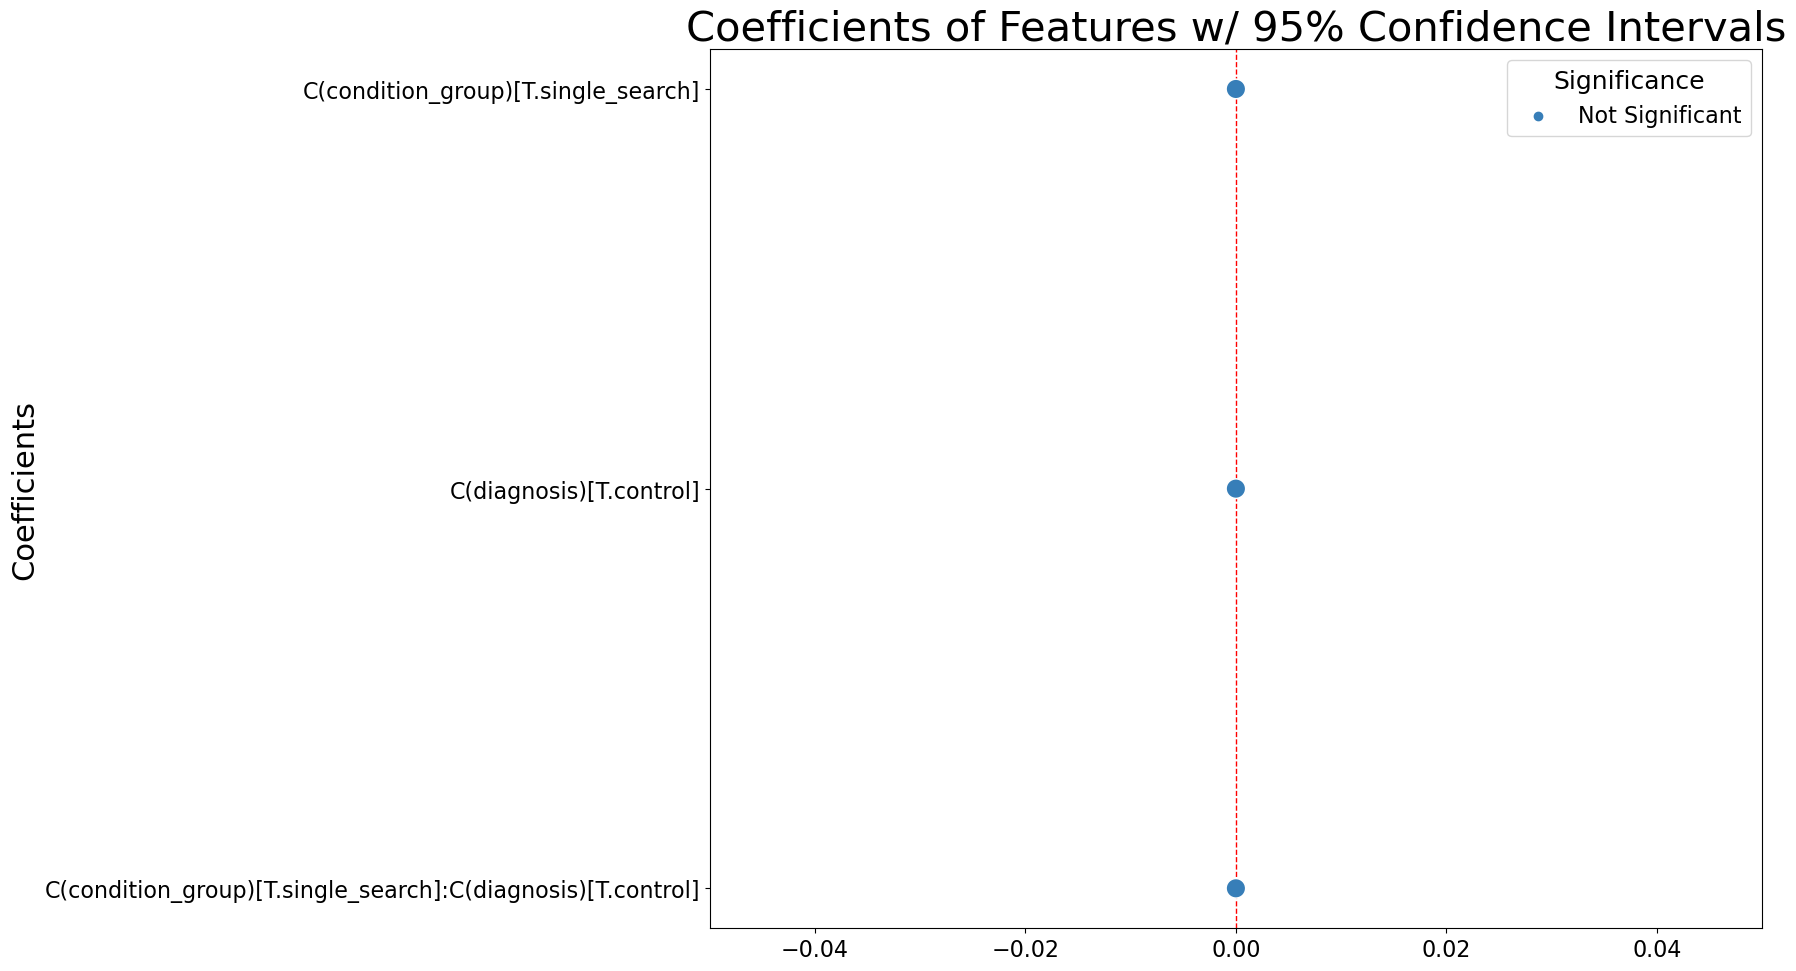

In [176]:
plt.rcParams.update({
    'font.size': 16,       # Base font size for ticks and text
    'axes.titlesize': 30,  # Title font
    'axes.labelsize': 22,  # Axis label font
    'xtick.labelsize': 16, # X-tick font
    'ytick.labelsize': 16, # Y-tick font
    'legend.fontsize': 16, # Legend font
    'legend.title_fontsize': 18  # Legend title font
})
coefplot_gap(model, multiple_models=False, fig_name='Simple Linear')
#nothing matters other than conditions (Faster 13 or 9)

In [85]:
pg.normality(data=vs_eeg, dv='P3_amplitude', group='diagnosis')

,W,pval,normal
diagnosis,,,
control,0.858451,4.270918e-09,False
asd,0.975463,5.919672e-01,True


In [86]:
pg.sphericity(data=vs_eeg, dv='P3_amplitude', subject='subject', within='condition_group', method='mauchly')

(True, nan, nan, 1, 1.0)

In [84]:
pg.homoscedasticity(data=vs_eeg, dv='P3_amplitude', group='diagnosis', method='levene')

,W,pval,equal_var
levene,3.334895,0.069827,True


In [74]:
p3_anova = pg.mixed_anova(
    dv='P3_amplitude',
    within='condition_group',
    between='diagnosis',
    subject='subject',
    data=vs_eeg
).round(4)
p3_anova

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,diagnosis,0.0,1,68,0.0,7.4590,0.0080,0.0988,NaN
1,condition_group,0.0,1,68,0.0,16.0820,0.0002,0.1913,1.0
2,Interaction,0.0,1,68,0.0,0.0401,0.8418,0.0006,NaN


In [101]:
post_hocs = pg.pairwise_tests(dv='P3_amplitude', within='condition_group',
                               subject='subject', between = 'diagnosis', padjust='fdr_bh', data=vs_eeg).round(5)
post_hocs

,Contrast,condition_group,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,condition_group,-,conjunction_search,single_search,True,True,-4.03843,69.00000,two-sided,0.00014,NaN,nan,154.815,-0.23753
1,diagnosis,-,asd,control,False,True,2.32253,18.54859,two-sided,0.03175,NaN,nan,2.513,0.78673
2,condition_group * diagnosis,conjunction_search,asd,control,False,True,2.27592,19.53799,two-sided,0.03428,0.03993,fdr_bh,2.309,0.73127
3,condition_group * diagnosis,single_search,asd,control,False,True,2.21694,17.75335,two-sided,0.03993,0.03993,fdr_bh,2.079,0.78957


In [177]:
# Test the effects of group and condition on rt while accoutning for sex, age and site

# Create mixed effects model
model_formula = "P3_amplitude ~ C(condition_group) * C(diagnosis)"

# Fit the model
model = smf.mixedlm(model_formula, vs_eeg, groups=vs_eeg["subject"],re_formula="~1").fit()

# Print the summary
model_summary = model.summary()
model_summary

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
                                Mixed Linear Model Regression Results
======================================================================================================
Model:                            MixedLM               Dependent Variable:               P3_amplitude
No. Observations:                 151                   Method:                           REML        
No. Groups:                       81                    Scale:                            0.0000      
Min. group size:                  1                     Log-Likelihood:                   1663.4309   
Max. group size:                  2                     Converged:                        Yes         
Mean group size:                  1.9                                                                 
------------------------------------------------------------------------------------------------------
                                                            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------------
Intercept                                                    0.000    0.000  9.874 0.000  0.000  0.000
C(condition_group)[T.single_search]                          0.000    0.000  1.990 0.047  0.000  0.000
C(diagnosis)[T.control]                                     -0.000    0.000 -2.416 0.016 -0.000 -0.000
C(condition_group)[T.single_search]:C(diagnosis)[T.control] -0.000    0.000 -0.265 0.791 -0.000  0.000
Group Var                                                    0.000    0.000                           
======================================================================================================

"""

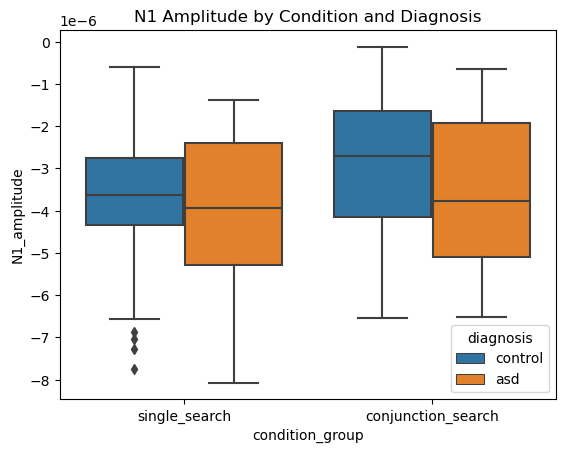

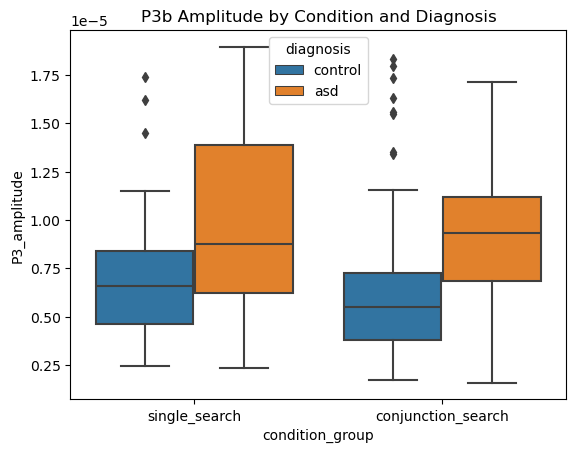

In [64]:
# N1 Boxplot
sns.boxplot(data=vs_eeg, x='condition_group', y='N1_amplitude', hue='diagnosis')
plt.title('N1 Amplitude by Condition and Diagnosis')
plt.show()

# P3b Boxplot
sns.boxplot(data=vs_eeg, x='condition_group', y='P3_amplitude', hue='diagnosis')
plt.title('P3b Amplitude by Condition and Diagnosis')
plt.show()

## N1 analysis for amplitude and latency

In [65]:
vs_eeg.groupby(['condition_group', 'diagnosis'])[['N1_amplitude', 'N1_latency']].mean()

N1_amplitude  N1_latency
condition_group    diagnosis                          
conjunction_search asd           -0.000004    0.115294
                   control       -0.000003    0.120119
single_search      asd           -0.000004    0.113526
                   control       -0.000004    0.122839

In [66]:
n1_amp_pivot = vs_eeg.pivot_table(index=['subject', 'diagnosis'], 
                                  columns='condition_group', 
                                  values='N1_amplitude').dropna()
n1_lat_pivot = vs_eeg.pivot_table(index=['subject', 'diagnosis'], 
                                  columns='condition_group', 
                                  values='N1_latency').dropna()

In [67]:
ttest_n1_amp = ttest_rel(n1_amp_pivot['conjunction_search'], n1_amp_pivot['single_search'])
ttest_n1_lat = ttest_rel(n1_lat_pivot['conjunction_search'], n1_lat_pivot['single_search'])

print("🔬 Paired t-test N1 Amplitude:", ttest_n1_amp)
print("🔬 Paired t-test N1 Latency:", ttest_n1_lat)

🔬 Paired t-test N1 Amplitude: TtestResult(statistic=3.7479725936227686, pvalue=0.0003666191948103924, df=69)
🔬 Paired t-test N1 Latency: TtestResult(statistic=-0.19808661157454885, pvalue=0.8435597474597893, df=69)


In [68]:
# N1 Amplitude ANOVA
#model_amp = ols("N1_amplitude ~ C(condition_group) * C(diagnosis)", data=vs_eeg).fit()
#anova_amp = sm.stats.anova_lm(model_amp, typ=2)

# N1 Latency ANOVA
#model_lat = ols("N1_latency ~ C(condition_group) * C(diagnosis)", data=vs_eeg).fit()
#nova_lat = sm.stats.anova_lm(model_lat, typ=2)

#print("N1 Amplitude ANOVA:\n", anova_amp)
#print("\nN1 Latency ANOVA:\n", anova_lat)

📈 N1 Amplitude ANOVA:
                                        sum_sq     df         F    PR(>F)
C(condition_group)               2.462984e-11    1.0  8.520020  0.004066
C(diagnosis)                     9.462169e-12    1.0  3.273179  0.072464
C(condition_group):C(diagnosis)  2.017981e-13    1.0  0.069807  0.791989
Residual                         4.249505e-10  147.0       NaN       NaN

📈 N1 Latency ANOVA:
                                    sum_sq     df         F    PR(>F)
C(condition_group)               0.000103    1.0  0.315021  0.575470
C(diagnosis)                     0.001400    1.0  4.283182  0.040242
C(condition_group):C(diagnosis)  0.000138    1.0  0.421444  0.517230
Residual                         0.048044  147.0       NaN       NaN


In [77]:
n1_l_anova = pg.mixed_anova(
    dv='N1_latency',
    within='condition_group',
    between='diagnosis',
    subject='subject',
    data=vs_eeg
).round(4)
n1_l_anova

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,diagnosis,0.0015,1,68,0.0015,3.7700,0.0563,0.0525,NaN
1,condition_group,0.0000,1,68,0.0000,0.0389,0.8443,0.0006,1.0
2,Interaction,0.0001,1,68,0.0001,0.3904,0.5342,0.0057,NaN


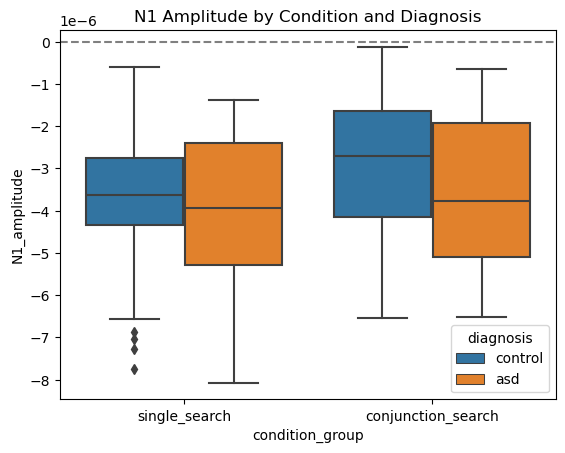

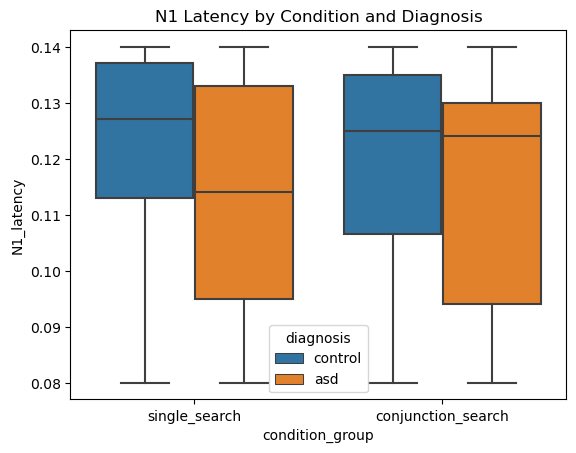

In [69]:
# amplitude
sns.boxplot(data=vs_eeg, x='condition_group', y='N1_amplitude', hue='diagnosis')
plt.title('N1 Amplitude by Condition and Diagnosis')
plt.axhline(0, color='gray', linestyle='--')
plt.show()
#latency
sns.boxplot(data=vs_eeg, x='condition_group', y='N1_latency', hue='diagnosis')
plt.title('N1 Latency by Condition and Diagnosis')
plt.show()

In [78]:
p3_l__anova = pg.mixed_anova(
    dv='P3_latency',
    within='condition_group',
    between='diagnosis',
    subject='subject',
    data=vs_eeg
).round(4)
p3_l__anova

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,diagnosis,0.0021,1,68,0.0021,0.5374,0.4660,0.0078,NaN
1,condition_group,0.0065,1,68,0.0065,2.8144,0.0980,0.0397,1.0
2,Interaction,0.0043,1,68,0.0043,1.8333,0.1802,0.0263,NaN
